# Project 4 Analysis

_Isaiah Osborne_

## Import Data

Person 3: Data Exploration & Visualization
- Perform initial dataset exploration (data summary, descriptive statistics, checking for missing values).
- Create visualizations for key findings:
- Property value differences based on covenant density.
- Loan approval disparities.
- Demographic and economic patterns.
- Ensure visualizations effectively support the report's key claims.
Help with slide preparation for the presentation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("../../Data/mortgage_covenant_data.csv")

## Dataset Exploration

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

`covenant_density` has several missing values - let's see what's going with it.

In [5]:
data["covenant_density"].value_counts()

covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64

It looks like the number of covenants is fairly unbalanced? Most of these don't have any covenants, which is good! We'll need to make sure this unbalanced data doesn't show up as bias in our algorithms. It could just try to sweep the covenants "under the rug" and not account for their impact.

## Data Bias

Let's see if we can unearth any sort of bias on our dataset.

In [6]:
data

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,NaN
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,NaN
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,NaN
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,NaN


In [16]:
data.value_counts("derived_race")

derived_race
White                                        63627
Race Not Available                           22811
Asian                                         5905
Black or African American                     5199
Joint                                         2427
American Indian or Alaska Native               709
2 or more minority races                       135
Native Hawaiian or Other Pacific Islander      113
Free Form Text Only                              5
Name: count, dtype: int64

Our race data here is pretty skewed to not have race... let's see how the prices breakdown across the different races.

In [ ]:
racePrices = data.groupby(["derived_race"])["property_value"].mean()

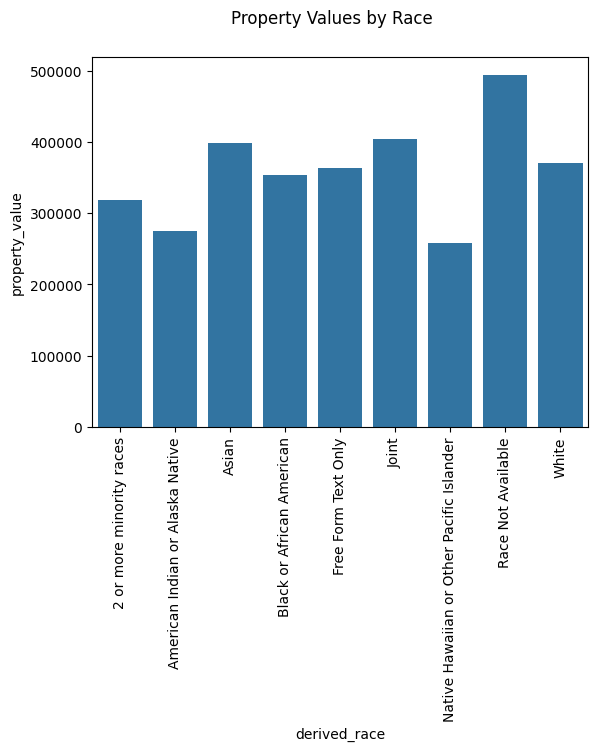

In [23]:
ax = sns.barplot(x=racePrices.index, y=racePrices)
plt.suptitle("Property Values by Race")
ax.tick_params(axis="x", rotation=90)

Ok, it looks like there is probably some collection bias going on here. It looks like not having race actually makes our property values lower? It looks like there is definitely a decrease in property values in minority neighborhoods.

In [24]:
data

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,NaN
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,NaN
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,NaN
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,NaN


In [28]:
data.value_counts("covenant_density")

covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64

In [33]:
data.groupby(["covenant_density", "derived_race"])["derived_race"].count()

covenant_density  derived_race                             
High (101-200)    2 or more minority races                        5
                  American Indian or Alaska Native                9
                  Asian                                          62
                  Black or African American                      46
                  Joint                                          64
                  Native Hawaiian or Other Pacific Islander       2
                  Race Not Available                            402
                  White                                        1130
Low (1-50)        2 or more minority races                        7
                  American Indian or Alaska Native               34
                  Asian                                         264
                  Black or African American                     427
                  Joint                                         145
                  Native Hawaiian or Other Pacific Islan

Within the entire dataset, most of our properties don't have race data. Once we move into areas with covenants, then we suddenly have race data again. It looks like whatever data collection process we used is biased to only collect race data for areas known to have covenants. As we have more covenants, we have significantly better race data. Our race data is only consistent for areas with several covenants.

These areas probably skew whiter than average, with a significant majority of the _Very High_ area being white. This data is biased toward having good data for the covenant areas, and not as high quality everywhere else.